# De-Time Method Gallery

This notebook is a runnable onboarding gallery for the retained
De-Time method surface. Each section uses the public
`DecompositionConfig`, `decompose`, and `MethodRegistry` objects.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Prefer the checkout when this notebook is run inside the repository.
repo_src = Path.cwd() / "src"
if (repo_src / "detime").exists():
    sys.meta_path[:] = [
        finder for finder in sys.meta_path
        if finder.__class__.__module__ != "_de_time_editable"
    ]
    sys.path.insert(0, str(repo_src))

from detime import DecompositionConfig, MethodRegistry, decompose

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.0),
        "figure.dpi": 130,
        "savefig.dpi": 220,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

rng = np.random.default_rng(42)
t = np.arange(96, dtype=float)
seasonal = np.sin(2.0 * np.pi * t / 12.0)
slow = 0.018 * t + 0.25 * np.sin(2.0 * np.pi * t / 48.0)
noise = 0.05 * rng.standard_normal(t.shape)
series = slow + seasonal + noise
panel = np.column_stack(
    [
        series,
        0.8 * slow + np.sin(2.0 * np.pi * (t + 2.0) / 12.0) + 0.04 * rng.standard_normal(t.shape),
        1.15 * slow + 0.7 * np.sin(2.0 * np.pi * (t + 4.0) / 12.0) + 0.04 * rng.standard_normal(t.shape),
    ]
)

CASES = {
    "SSA": {"data": series, "config": {"method": "SSA", "params": {"window": 24, "rank": 6, "primary_period": 12}, "backend": "auto", "speed_mode": "exact"}},
    "STD": {"data": series, "config": {"method": "STD", "params": {"period": 12}, "backend": "auto"}},
    "STDR": {"data": series, "config": {"method": "STDR", "params": {"period": 12}, "backend": "auto"}},
    "MSSA": {"data": panel, "config": {"method": "MSSA", "params": {"window": 24, "rank": 6, "primary_period": 12}, "backend": "python", "channel_names": ["a", "b", "c"]}},
    "STL": {"data": series, "config": {"method": "STL", "params": {"period": 12}}},
    "MSTL": {"data": series, "config": {"method": "MSTL", "params": {"periods": [12, 24]}}},
    "ROBUST_STL": {"data": series, "config": {"method": "ROBUST_STL", "params": {"period": 12}}},
    "EMD": {"data": series, "config": {"method": "EMD", "params": {"primary_period": 12, "n_imfs": 4}}},
    "CEEMDAN": {"data": series, "config": {"method": "CEEMDAN", "params": {"primary_period": 12, "trials": 3, "noise_width": 0.03}}},
    "VMD": {"data": series, "config": {"method": "VMD", "params": {"K": 4, "alpha": 300.0, "primary_period": 12}}},
    "WAVELET": {"data": series, "config": {"method": "WAVELET", "params": {"wavelet": "db4", "level": 3}}},
    "MA_BASELINE": {"data": series, "config": {"method": "MA_BASELINE", "params": {"trend_window": 7, "season_period": 12}}},
    "MVMD": {"data": panel, "config": {"method": "MVMD", "params": {"K": 4, "alpha": 300.0, "primary_period": 12}, "channel_names": ["a", "b", "c"]}},
    "MEMD": {"data": panel, "config": {"method": "MEMD", "params": {"primary_period": 12}, "channel_names": ["a", "b", "c"]}},
    "GABOR_CLUSTER": {"data": series, "skip": "requires a trained GaborClusterModel or model_path plus the experimental clustering backend"},
}

GALLERY_RESULTS = []


In [2]:
def _plot_vector(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 2:
        return arr[:, 0]
    return arr


def _style_gallery_axis(ax, title):
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="y", alpha=0.22, color="#94a3b8", linewidth=0.8)
    ax.grid(False, axis="x")
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.tick_params(colors="#334155")
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", color="#0f172a")


def run_gallery_case(name):
    case = CASES[name]
    metadata = MethodRegistry.get_metadata(name)
    print(f"{name}: {metadata['summary']}")
    if "skip" in case:
        row = {
            "method": name,
            "status": "skipped",
            "reason": case["skip"],
            "input_mode": metadata["input_mode"],
            "output_shape": "",
            "residual_rmse": np.nan,
        }
        GALLERY_RESULTS.append(row)
        display(pd.DataFrame([row]))
        return

    data = case["data"]
    cfg = DecompositionConfig(**case["config"])
    try:
        result = decompose(data, cfg)
    except Exception as exc:
        row = {
            "method": name,
            "status": "skipped",
            "reason": f"{type(exc).__name__}: {exc}",
            "input_mode": metadata["input_mode"],
            "output_shape": "",
            "residual_rmse": np.nan,
        }
        GALLERY_RESULTS.append(row)
        display(pd.DataFrame([row]))
        return

    original = _plot_vector(data)
    trend = _plot_vector(result.trend)
    season = _plot_vector(result.season)
    residual = _plot_vector(result.residual)
    reconstruction = trend + season + residual
    rmse = float(np.sqrt(np.mean((original - reconstruction) ** 2)))

    row = {
        "method": name,
        "status": "ran",
        "reason": "",
        "input_mode": metadata["input_mode"],
        "output_shape": str(np.asarray(result.trend).shape),
        "residual_rmse": round(rmse, 8),
    }
    GALLERY_RESULTS.append(row)
    display(pd.DataFrame([row]))

    fig, ax = plt.subplots(facecolor="#f8fafc")
    ax.plot(original, label="input", color="#0f172a", linewidth=1.6)
    ax.plot(trend, label="trend", color="#2563eb", linewidth=1.4)
    ax.plot(season, label="season", color="#0f766e", linewidth=1.2)
    ax.plot(residual, label="residual", color="#f97316", linewidth=1.0, alpha=0.85)
    _style_gallery_axis(ax, f"{name} decomposition")
    ax.set_xlabel("time step")
    ax.legend(loc="upper right", ncol=2, fontsize=8, frameon=True, framealpha=0.92)
    fig.tight_layout()
    plt.show()


## `SSA` - Univariate SSA


SSA: Singular spectrum analysis for structured univariate decomposition.


,method,status,reason,input_mode,output_shape,residual_rmse
0,SSA,ran,,univariate,"(96,)",0.0


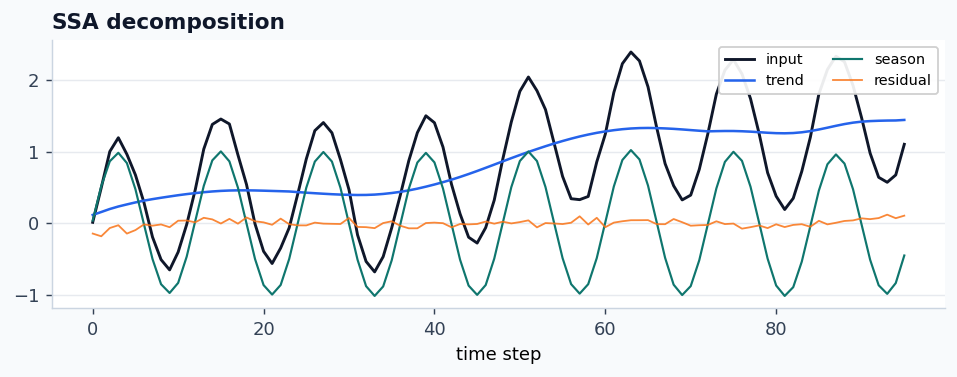

In [3]:
run_gallery_case("SSA")


## `STD` - Seasonal-trend decomposition


STD: Fast seasonal-trend decomposition with dispersion-aware diagnostics.


,method,status,reason,input_mode,output_shape,residual_rmse
0,STD,ran,,channelwise,"(96,)",0.0


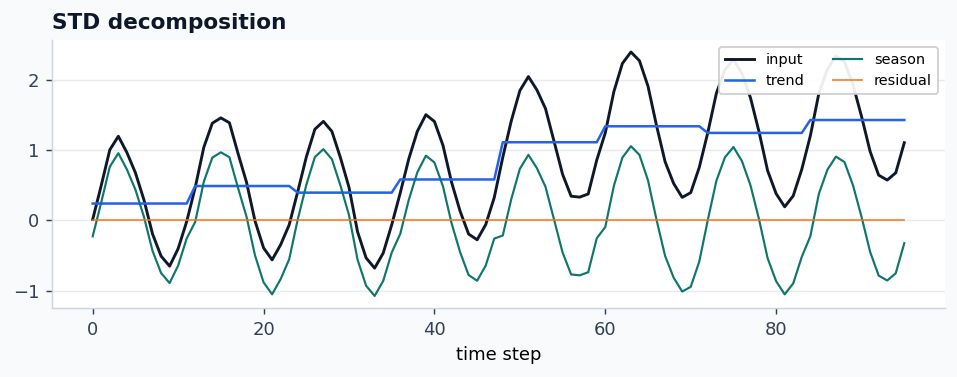

In [4]:
run_gallery_case("STD")


## `STDR` - Robust seasonal-trend decomposition


STDR: Robust seasonal-trend decomposition for noisier periodic signals.


,method,status,reason,input_mode,output_shape,residual_rmse
0,STDR,ran,,channelwise,"(96,)",0.0


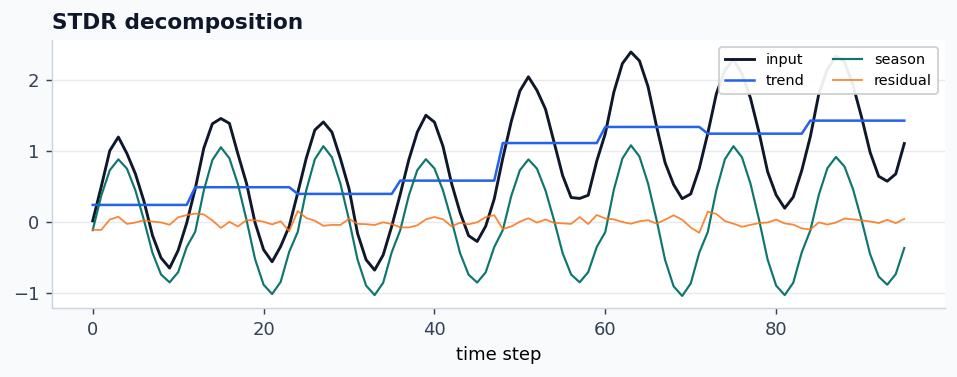

In [5]:
run_gallery_case("STDR")


## `MSSA` - Multivariate SSA


MSSA: Multivariate SSA for shared-structure decomposition across channels.


,method,status,reason,input_mode,output_shape,residual_rmse
0,MSSA,ran,,multivariate,"(96, 3)",0.0


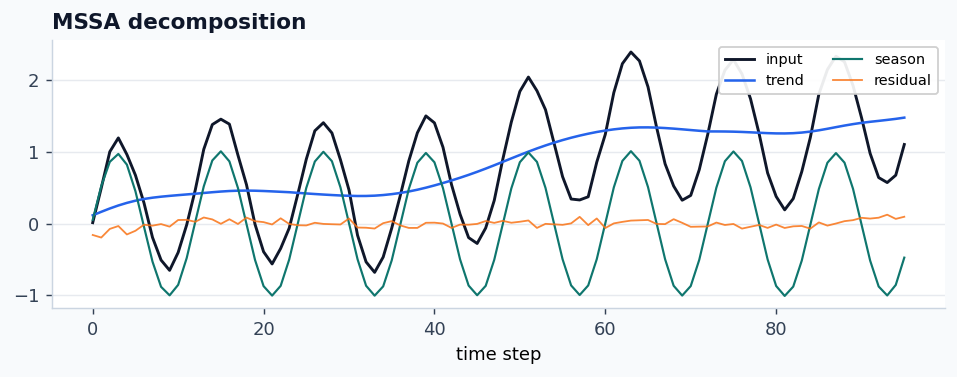

In [6]:
run_gallery_case("MSSA")


## `STL` - Statsmodels STL wrapper


STL: Classical STL wrapped into the De-Time workflow contract.


,method,status,reason,input_mode,output_shape,residual_rmse
0,STL,ran,,univariate,"(96,)",0.0


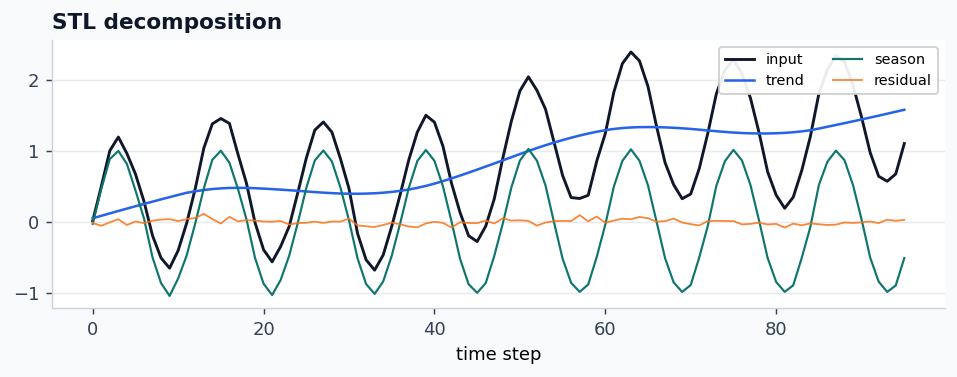

In [7]:
run_gallery_case("STL")


## `MSTL` - Statsmodels MSTL wrapper


MSTL: Statsmodels MSTL wrapped into the De-Time workflow surface.


,method,status,reason,input_mode,output_shape,residual_rmse
0,MSTL,ran,,univariate,"(96,)",0.0


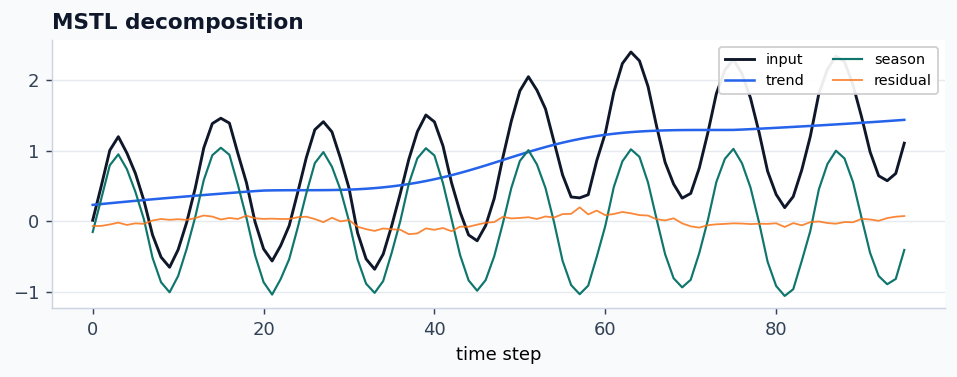

In [8]:
run_gallery_case("MSTL")


## `ROBUST_STL` - Robust STL wrapper


ROBUST_STL: Robust STL-style decomposition wrapped for reproducible workflows.


,method,status,reason,input_mode,output_shape,residual_rmse
0,ROBUST_STL,ran,,univariate,"(96,)",0.0


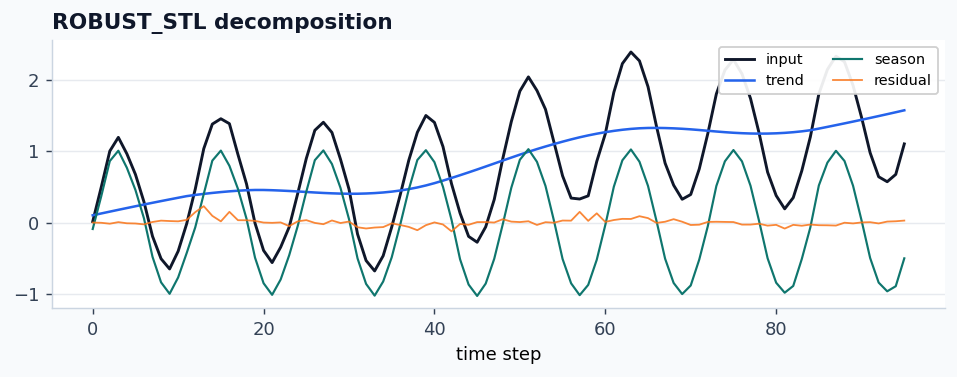

In [9]:
run_gallery_case("ROBUST_STL")


## `EMD` - Empirical mode decomposition


In [10]:
run_gallery_case("EMD")


EMD: Empirical mode decomposition under the De-Time result contract.


,method,status,reason,input_mode,output_shape,residual_rmse
0,EMD,skipped,ImportError: PyEMD is required for EMD decompo...,univariate,,NaN


## `CEEMDAN` - Noise-assisted EMD


In [11]:
run_gallery_case("CEEMDAN")


CEEMDAN: Noise-assisted EMD variant for more stable IMF extraction.


,method,status,reason,input_mode,output_shape,residual_rmse
0,CEEMDAN,skipped,ImportError: PyEMD>=1.0 is required for CEEMDA...,univariate,,NaN


## `VMD` - Variational mode decomposition


In [12]:
run_gallery_case("VMD")


VMD: Variational mode decomposition integrated into the common workflow layer.


,method,status,reason,input_mode,output_shape,residual_rmse
0,VMD,skipped,ImportError: vmdpy is required for VMD decompo...,univariate,,NaN


## `WAVELET` - Wavelet decomposition


WAVELET: Wavelet-based decomposition exposed through the common output contract.


,method,status,reason,input_mode,output_shape,residual_rmse
0,WAVELET,ran,,univariate,"(96,)",0.0


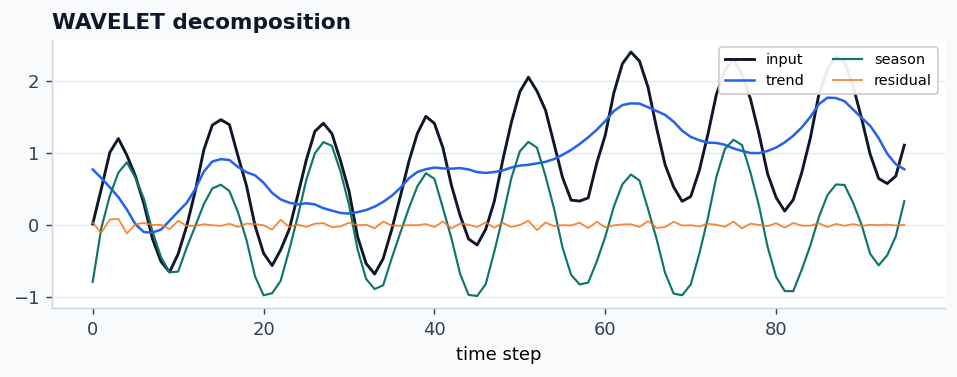

In [13]:
run_gallery_case("WAVELET")


## `MA_BASELINE` - Moving-average baseline


MA_BASELINE: Simple moving-average baseline for smoke tests and lightweight workflows.


,method,status,reason,input_mode,output_shape,residual_rmse
0,MA_BASELINE,ran,,univariate,"(96,)",0.0


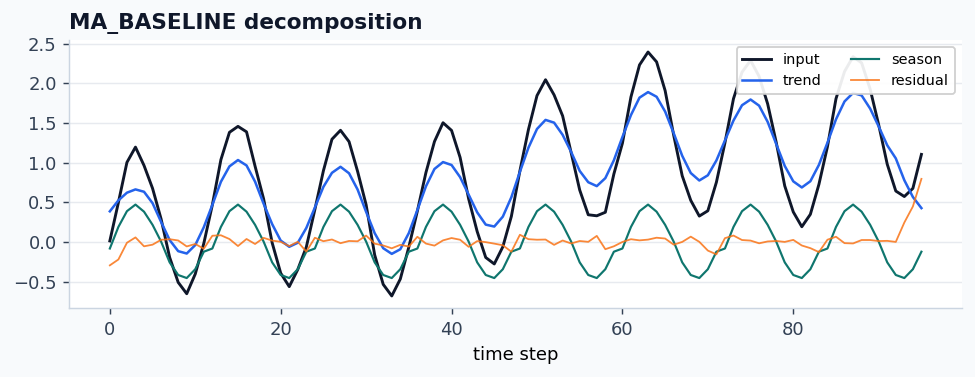

In [14]:
run_gallery_case("MA_BASELINE")


## `MVMD` - Optional multivariate VMD backend


In [15]:
run_gallery_case("MVMD")


MVMD: Optional multivariate VMD backend for shared frequency structure.


,method,status,reason,input_mode,output_shape,residual_rmse
0,MVMD,skipped,ImportError: MVMD requires an optional multiva...,multivariate,,NaN


## `MEMD` - Optional multivariate EMD backend


In [16]:
run_gallery_case("MEMD")


MEMD: Optional multivariate EMD backend for shared oscillatory structure.


,method,status,reason,input_mode,output_shape,residual_rmse
0,MEMD,skipped,ImportError: MEMD requires an optional multiva...,multivariate,,NaN


## `GABOR_CLUSTER` - Experimental Gabor clustering path


In [17]:
run_gallery_case("GABOR_CLUSTER")


GABOR_CLUSTER: Experimental clustering-based decomposition path.


,method,status,reason,input_mode,output_shape,residual_rmse
0,GABOR_CLUSTER,skipped,requires a trained GaborClusterModel or model_...,univariate,,NaN


## Summary


In [18]:
summary = pd.DataFrame(GALLERY_RESULTS)
display(summary)
ran = int((summary["status"] == "ran").sum())
skipped = int((summary["status"] == "skipped").sum())
print(f"Methods run: {ran}; skipped with explicit reason: {skipped}")


,method,status,reason,input_mode,output_shape,residual_rmse
0,SSA,ran,,univariate,"(96,)",0.0
1,STD,ran,,channelwise,"(96,)",0.0
2,STDR,ran,,channelwise,"(96,)",0.0
3,MSSA,ran,,multivariate,"(96, 3)",0.0
4,STL,ran,,univariate,"(96,)",0.0
5,MSTL,ran,,univariate,"(96,)",0.0
6,ROBUST_STL,ran,,univariate,"(96,)",0.0
7,EMD,skipped,ImportError: PyEMD is required for EMD decompo...,univariate,,NaN
8,CEEMDAN,skipped,ImportError: PyEMD>=1.0 is required for CEEMDA...,univariate,,NaN
9,VMD,skipped,ImportError: vmdpy is required for VMD decompo...,univariate,,NaN


Methods run: 9; skipped with explicit reason: 6
